In [1]:
from config import FILE_DATA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(FILE_DATA)

In [3]:
df.head(3)

,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt


In [4]:
df.describe(include='all')

,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
count,8500,8500.000000,8500,8500,8500,8500.000000,8500,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500
unique,8500,NaN,3,5,3,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,USR-00001,NaN,Female,Corporate 9-to-5,Intermediate,NaN,TikTok / Reels,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderate Debt
freq,1,NaN,4347,2838,3880,NaN,2198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4462
mean,NaN,34.355647,NaN,NaN,NaN,59.250000,NaN,55.153882,0.467765,33.222471,35.701412,40.671471,6.266209,21.735741,19.105859,2.766000,3.794671,NaN
std,NaN,11.584259,NaN,NaN,NaN,36.931991,NaN,19.850550,0.498989,51.935645,20.819390,17.444914,1.446258,3.069377,2.546459,1.695407,2.685153,NaN
min,NaN,18.000000,NaN,NaN,NaN,1.000000,NaN,10.000000,0.000000,0.000000,0.000000,6.000000,3.200000,8.100000,9.600000,0.000000,1.000000,NaN
25%,NaN,25.000000,NaN,NaN,NaN,31.000000,NaN,42.000000,0.000000,0.000000,21.000000,28.200000,5.240000,19.700000,17.400000,2.000000,1.100000,NaN
50%,NaN,32.000000,NaN,NaN,NaN,51.000000,NaN,55.000000,0.000000,0.000000,35.000000,37.600000,6.330000,21.900000,19.100000,3.000000,3.200000,NaN
75%,NaN,42.000000,NaN,NaN,NaN,79.000000,NaN,69.000000,1.000000,55.000000,50.000000,49.700000,7.350000,23.900000,20.800000,4.000000,5.600000,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   object 
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   object 
 3   occupation_type           8500 non-null   object 
 4   chronotype                8500 non-null   object 
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   primary_bedtime_app       8500 non-null   object 
 7   screen_brightness_pct     8500 non-null   int64  
 8   blue_light_filter_active  8500 non-null   int64  
 9   caffeine_post_5pm_mg      8500 non-null   int64  
 10  physical_activity_min     8500 non-null   int64  
 11  sleep_latency_min         8500 non-null   float64
 12  total_sleep_hours         8500 non-null   float64
 13  deep_sleep_pct            8500 non-null   float64
 14  rem_slee

# EDA

## Distribución

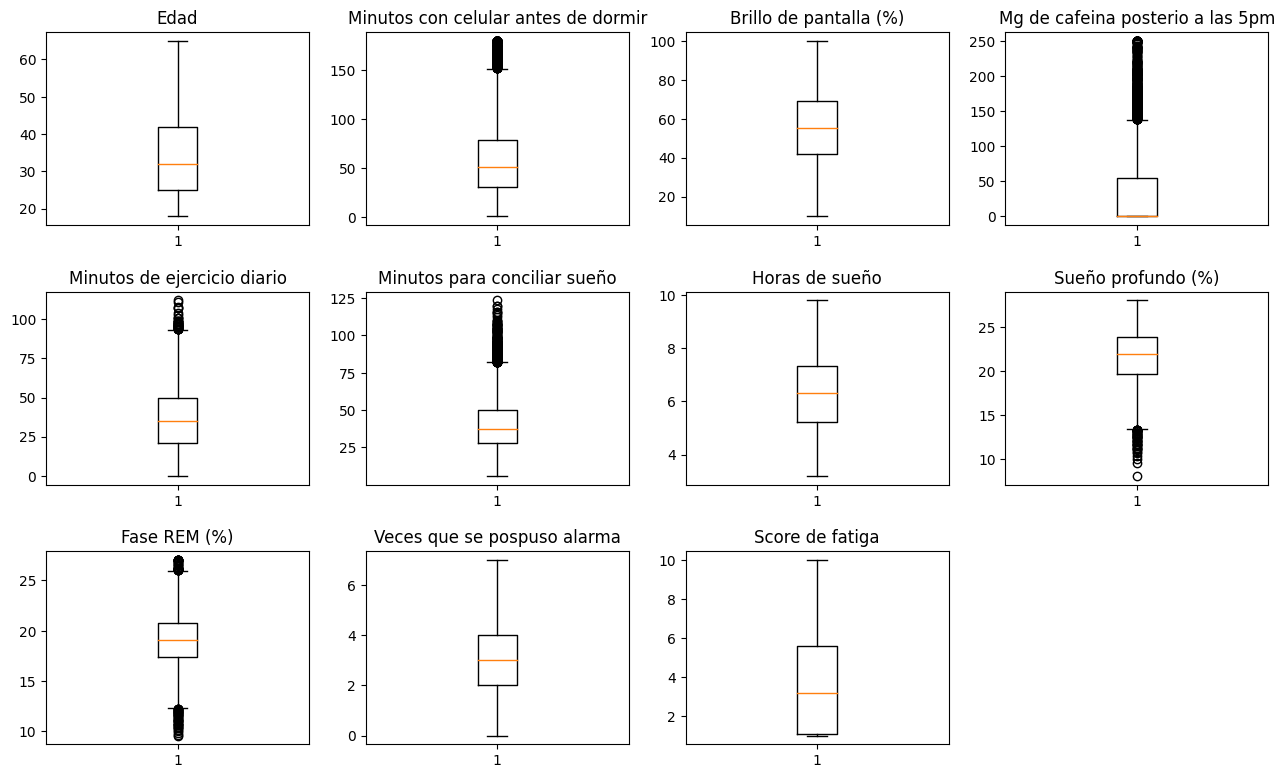

In [6]:
variables = ["age", "bedtime_phone_minutes", "screen_brightness_pct", "caffeine_post_5pm_mg", "physical_activity_min", "sleep_latency_min", "total_sleep_hours", "deep_sleep_pct", "rem_sleep_pct", "morning_alarm_snoozes", "next_day_fatigue_score"]
titulos = ["Edad", "Minutos con celular antes de dormir", "Brillo de pantalla (%)", "Mg de cafeina posterio a las 5pm", "Minutos de ejercicio diario", "Minutos para conciliar sueño", "Horas de sueño", "Sueño profundo (%)", "Fase REM (%)", "Veces que se pospuso alarma", "Score de fatiga"]

fig, axs = plt.subplots(3, 4, figsize = (13, 8))
axs = axs.flatten()

for i, var in enumerate(variables):
    axs[i].boxplot(df[var])
    axs[i].set_title(titulos[i])

fig.delaxes(axs[len(variables)])

plt.tight_layout(pad= 1.5)
plt.show()

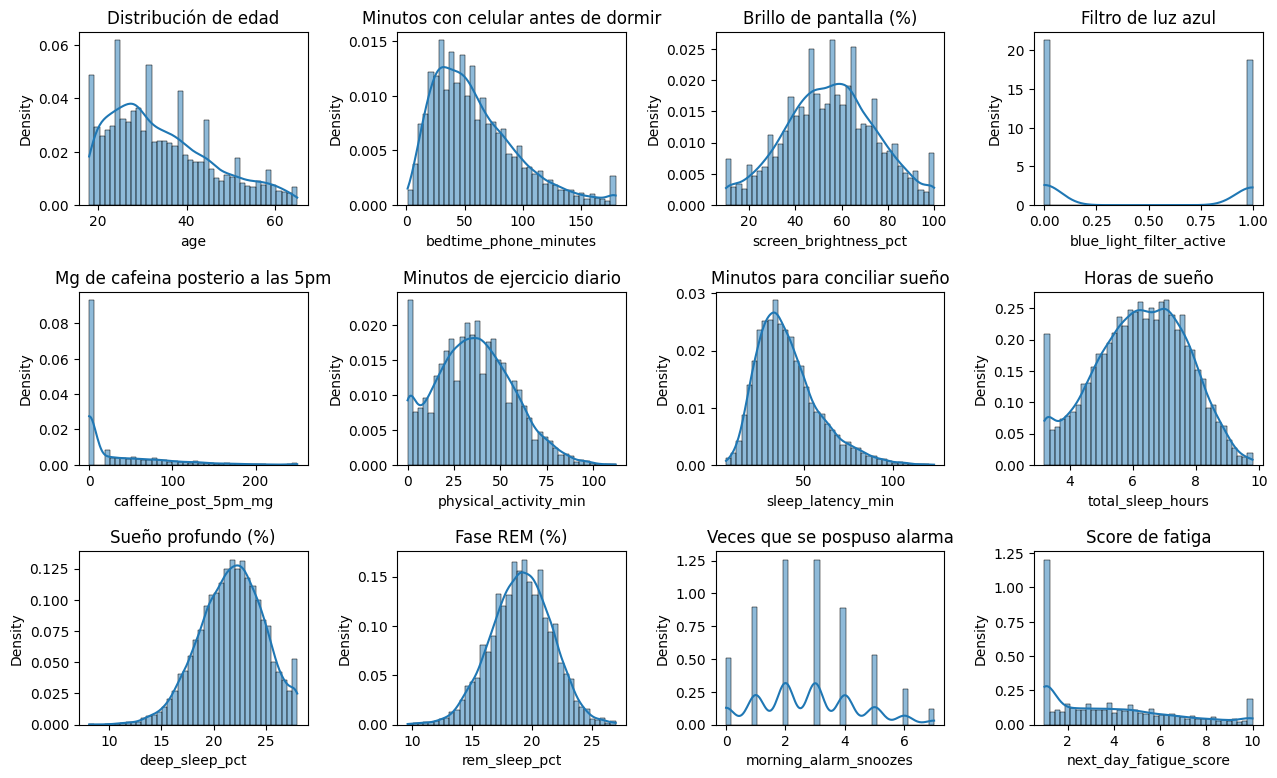

In [7]:
variables = ["age", "bedtime_phone_minutes", "screen_brightness_pct", "blue_light_filter_active", "caffeine_post_5pm_mg", "physical_activity_min", "sleep_latency_min", "total_sleep_hours", "deep_sleep_pct", "rem_sleep_pct", "morning_alarm_snoozes", "next_day_fatigue_score"]
titulos = ["Distribución de edad", "Minutos con celular antes de dormir", "Brillo de pantalla (%)", "Filtro de luz azul", "Mg de cafeina posterio a las 5pm", "Minutos de ejercicio diario", "Minutos para conciliar sueño", "Horas de sueño", "Sueño profundo (%)", "Fase REM (%)", "Veces que se pospuso alarma", "Score de fatiga"]

fig, axs = plt.subplots(3, 4, figsize = (13, 8))
axs = axs.flatten()
n_bins = 40

for i, var in enumerate(variables):
    sns.histplot(df[var], kde= True, bins= n_bins, stat="density", ax= axs[i])
    axs[i].set_title(titulos[i])

plt.tight_layout(pad = 1.5) # Evitar traslape entre gráficos
plt.show()

## Categóricos

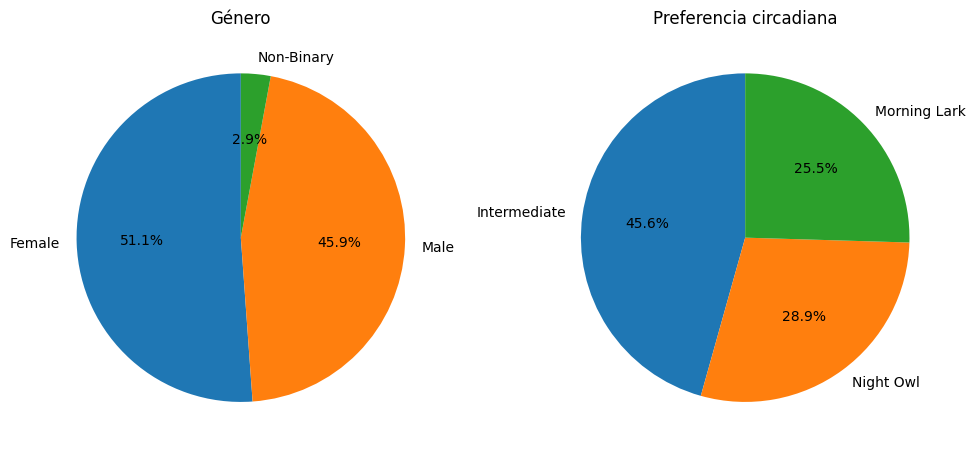

In [8]:
# pay plot -> gender, chronotype
fig, axs = plt.subplots(1, 2, figsize = (10, 8))

conteo = df["gender"].value_counts()
axs[0].pie(conteo, 
        labels = conteo.index, 
        autopct='%1.1f%%', 
        startangle=90)

conteo = df["chronotype"].value_counts()
axs[1].pie(conteo,
           labels = conteo.index,
           autopct = "%1.1f%%",
           startangle = 90)

axs[0].set_title("Género")
axs[1].set_title("Preferencia circadiana")

plt.tight_layout()
plt.show()

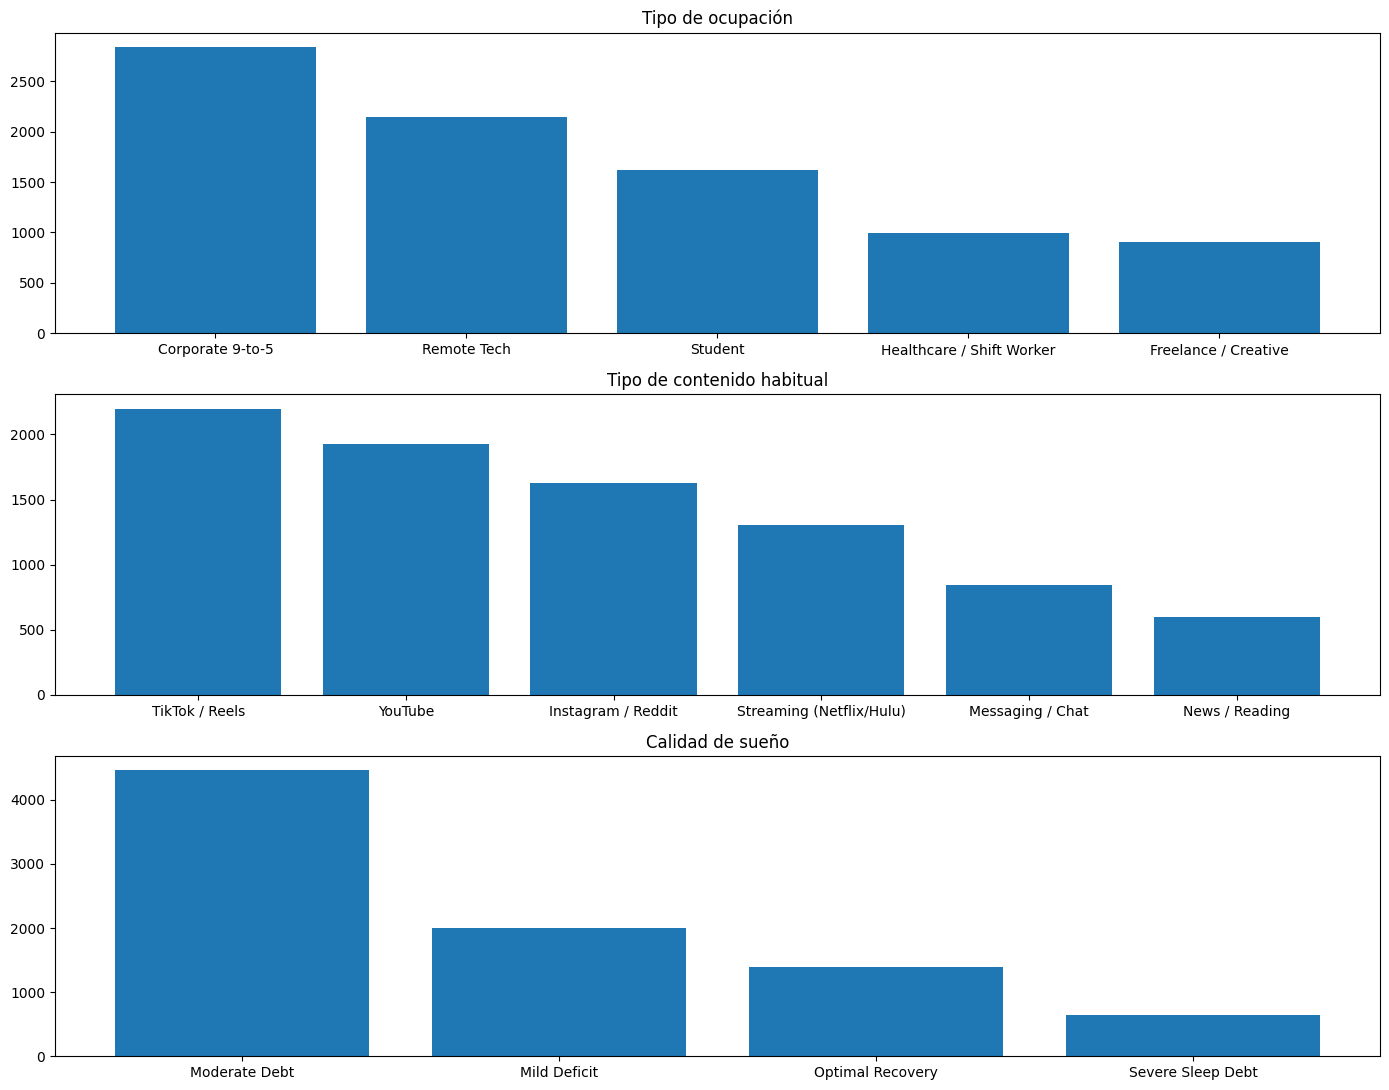

In [9]:
variables = ["occupation_type", "primary_bedtime_app", "sleep_debt_category"]
titulos = ["Tipo de ocupación", "Tipo de contenido habitual", "Calidad de sueño"]

fig, axs = plt.subplots(3, 1, figsize = (14, 11))

for i in range(len(variables)):
    conteo = df[variables[i]].value_counts()
    axs[i].bar(conteo.index, conteo)
    axs[i].set_title(titulos[i])

plt.tight_layout()
plt.show()

## Correlación

<Axes: >

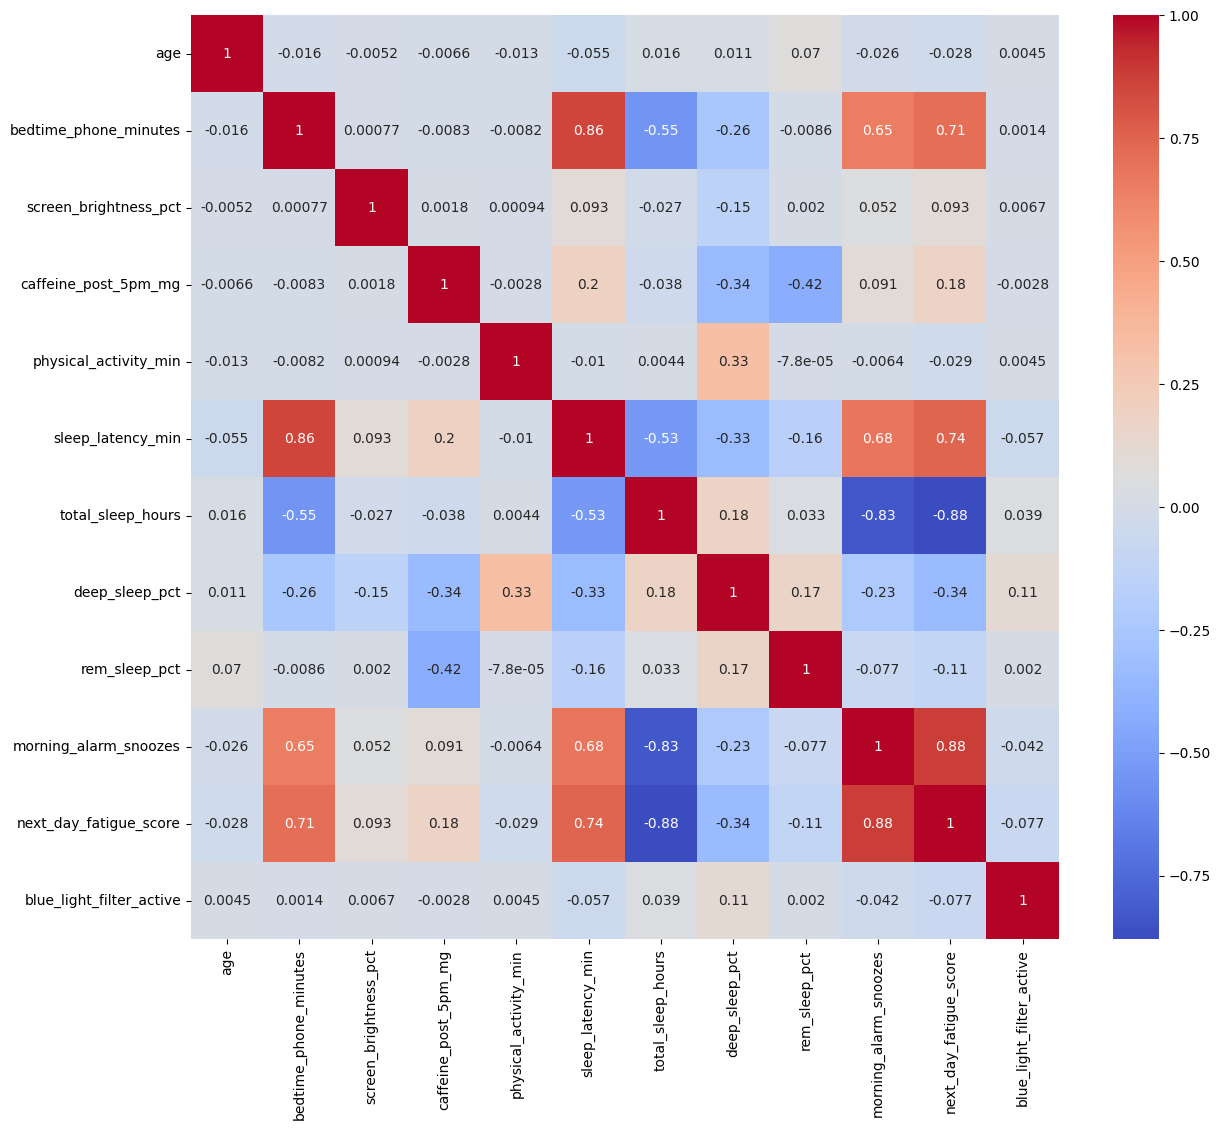

In [10]:
variables = ["age", "bedtime_phone_minutes", "screen_brightness_pct", "caffeine_post_5pm_mg", "physical_activity_min", "sleep_latency_min", "total_sleep_hours", "deep_sleep_pct", "rem_sleep_pct", "morning_alarm_snoozes", "next_day_fatigue_score", "blue_light_filter_active"]

matriz_correlacion = df[variables].corr()
plt.figure(figsize= (14, 12))
sns.heatmap(matriz_correlacion, 
            annot= True,
            cmap="coolwarm")

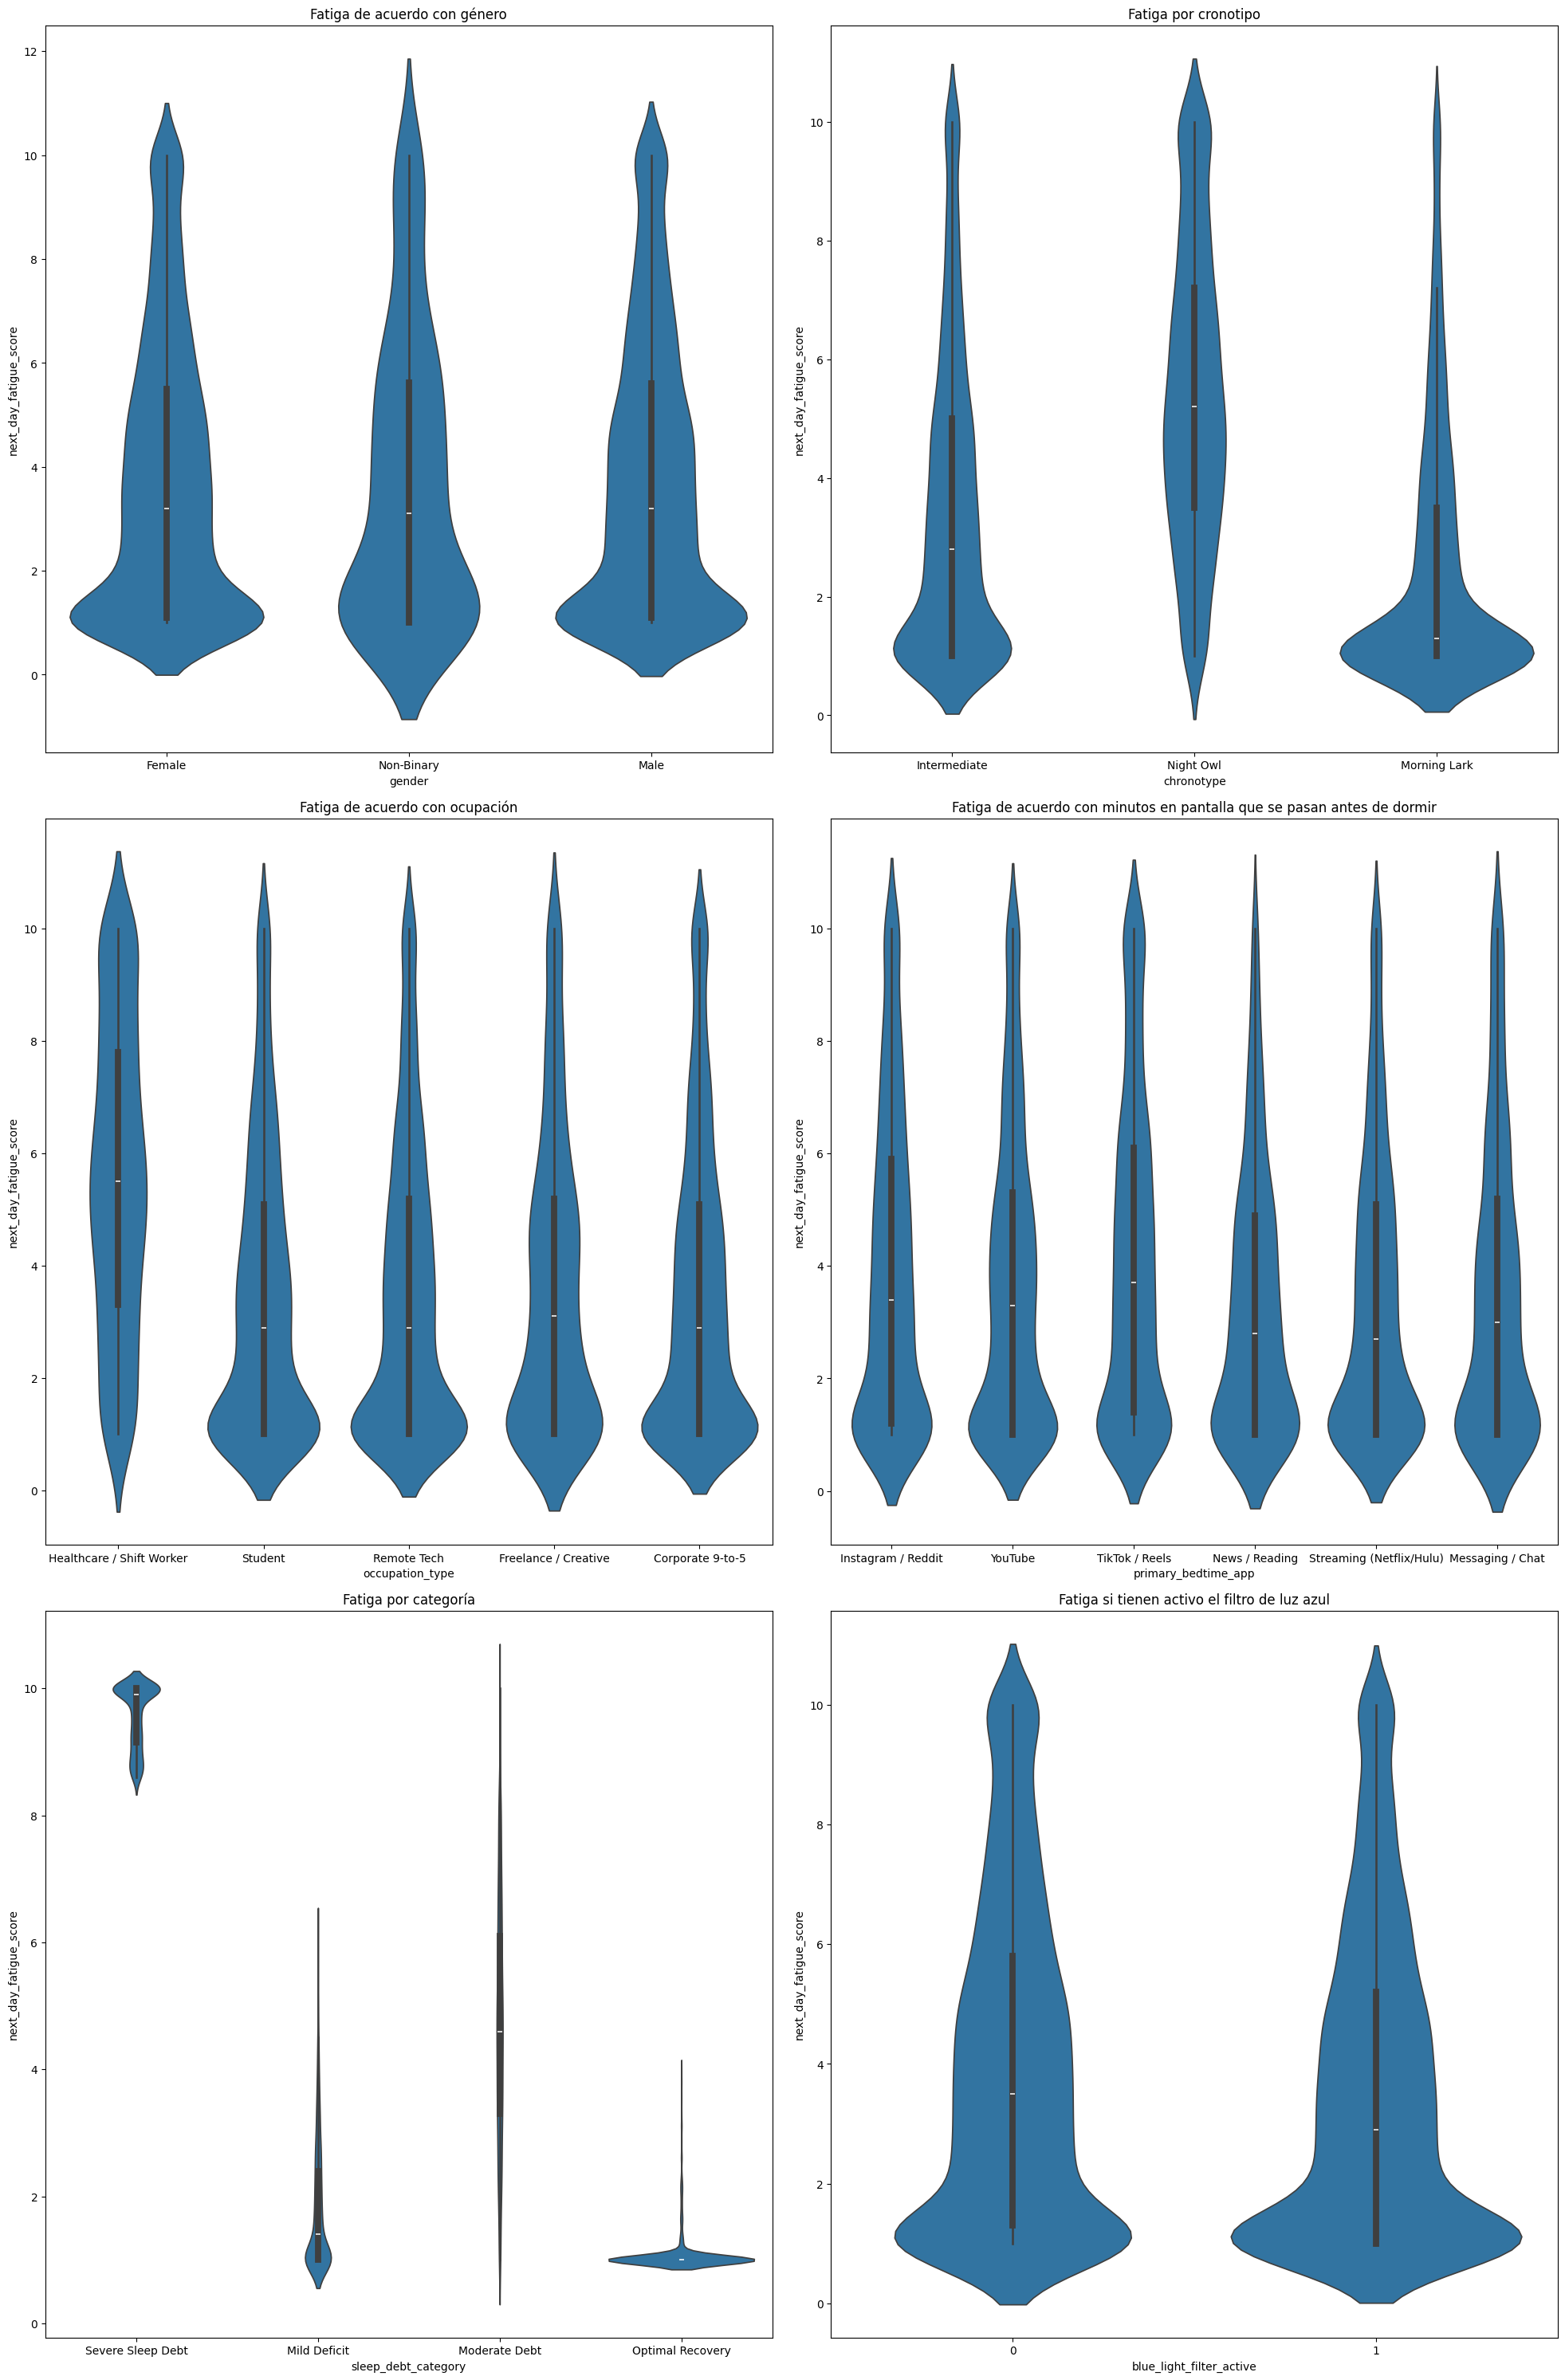

In [11]:
var_estudio = "next_day_fatigue_score"
variables = ["gender", "chronotype", "occupation_type", "primary_bedtime_app", "sleep_debt_category", "blue_light_filter_active"]
titulos = ["Fatiga de acuerdo con género", "Fatiga por cronotipo", "Fatiga de acuerdo con ocupación", "Fatiga de acuerdo con minutos en pantalla que se pasan antes de dormir", "Fatiga por categoría", "Fatiga si tienen activo el filtro de luz azul"]

fig, axs = plt.subplots(3, 2, figsize = (20,30))
axs = axs.flatten()

for i, var in enumerate(variables):
    sns.violinplot(df, x = var, y = var_estudio, ax = axs[i])
    axs[i].set_title(titulos[i])
    axs[i].set_box_aspect(1)

plt.tight_layout(pad= 1.2)
plt.show()

Observaciones:

1. Personas con cronotipo nocturno de media tienen má fatiga que los que no.

2. Trabajo en el área de la salud o con horarios diferentes vespertinos/nocturnos concentran a gente 2 puntos por encima en fatiga

3. Las apps tipo reel provocan ligera alta en el nivel de fatiga, mientras que leer y ver contenido largo, como series en Netflix, baja ligeramente la fatiga (antes de dormir)

4. No usar el filtro azul muestra evidencia de que las personas se fatigan más.

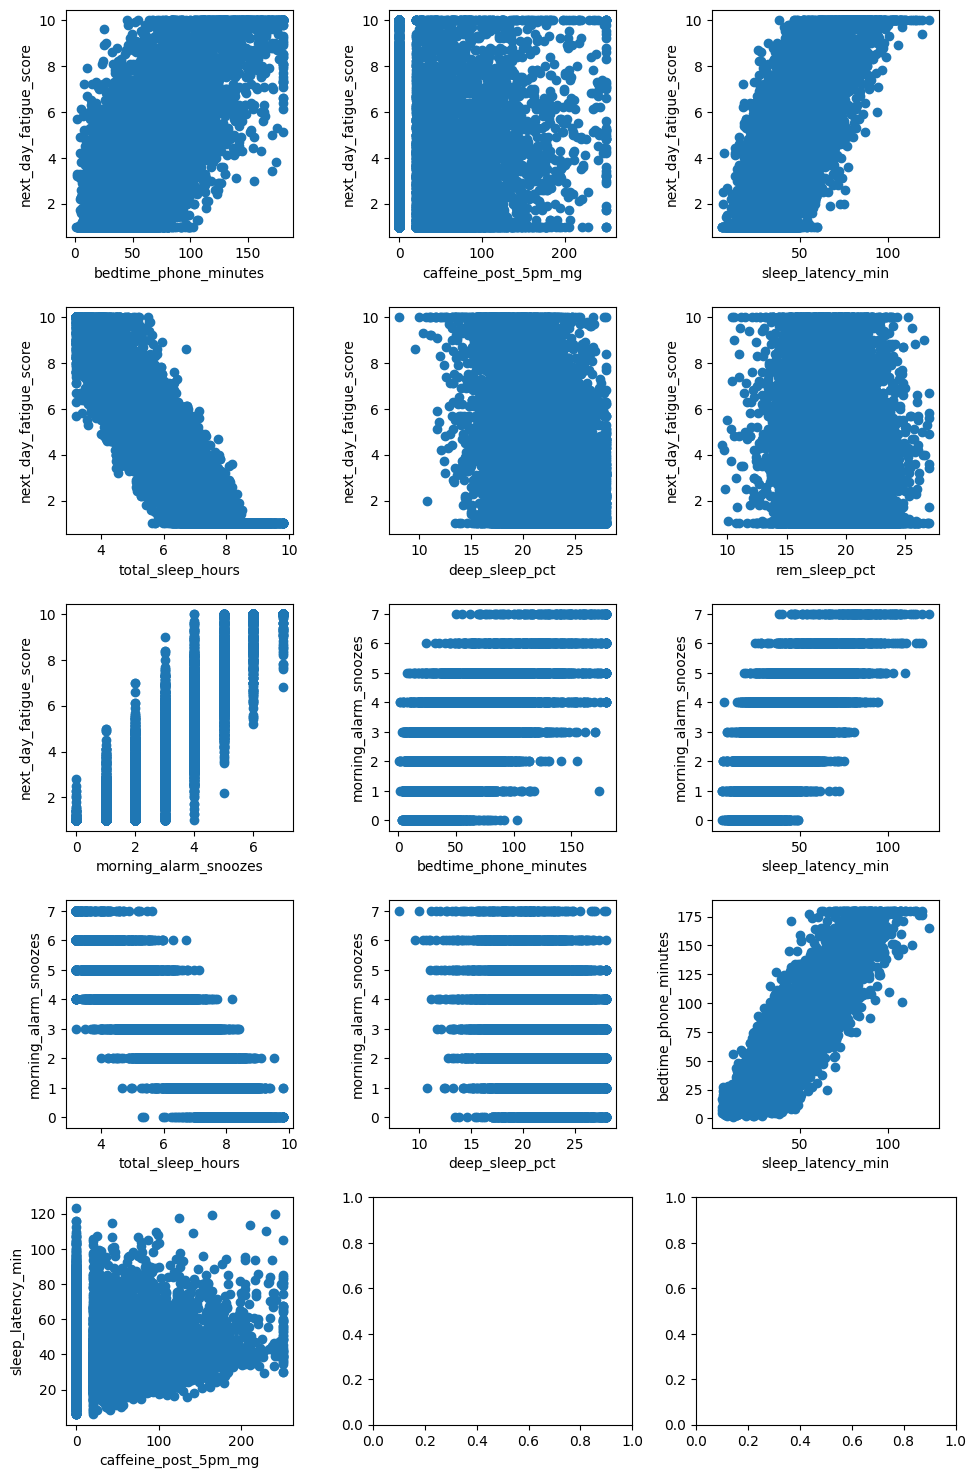

In [12]:
variables_lineal = {
    'next_day_fatigue_score': ['bedtime_phone_minutes', 'caffeine_post_5pm_mg', 'sleep_latency_min', 'total_sleep_hours', 'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes'],
    'morning_alarm_snoozes': ['bedtime_phone_minutes', 'sleep_latency_min', 'total_sleep_hours', 'deep_sleep_pct'],
    'bedtime_phone_minutes': ['sleep_latency_min'],
    'sleep_latency_min': ['caffeine_post_5pm_mg'],
}

fig, axs = plt.subplots(5, 3, figsize = (10, 15))
axs = axs.flatten()

i = 0
for var_principal, variables in variables_lineal.items():
    for var in variables:
        axs[i].scatter(x = df[var],y = df[var_principal])
        axs[i].set_xlabel(var)
        axs[i].set_ylabel(var_principal)
        axs[i].set_box_aspect(1)
        i += 1

plt.tight_layout(pad= 1.5)
plt.show()


Observaciones:

**1.** Dificil interpretabilidad en los datos. No se aprecia claramente en dónde se encuentra la mayoría de personas -> Sol. Crear hexabins

**2.** Aparición de relaciones lineales en:

        a. Minutos en teléfono antes de dormir y Score de fatiga: Más minutos en pantalla se correspone con más fatiga

        b. Latencia y score de fatiga: Tardar más en dormir provoca mayores niveles de fatiga

        c. Horas de sueño y score de fatiga: A más horas de sueño, menos fatiga se tiene

        d. Fatiga y veces que suena el despertador: A mayor número de alarmas, la fatiga es mayor [Interpretación: Personas fatigadas tienden a ignorar más el despertador]

        e. Minutos en teléfono antes de dormir y veces que suena despertador: A más minutos se use el teléfono antes de dormir, más veces se ignorará el despertador al día siguiente

        f. Latencia y veces que suena despertador: Mientras más tarde la persona en dormir, más ignorará el despertador

        g. Latencia y horas totales de sueño: Mientras más duerma, menos ignorará la alarma

**3.** El porcentaje de sueño profundo y REM no cambia significativamente idenpendientemente del nivel de fatiga

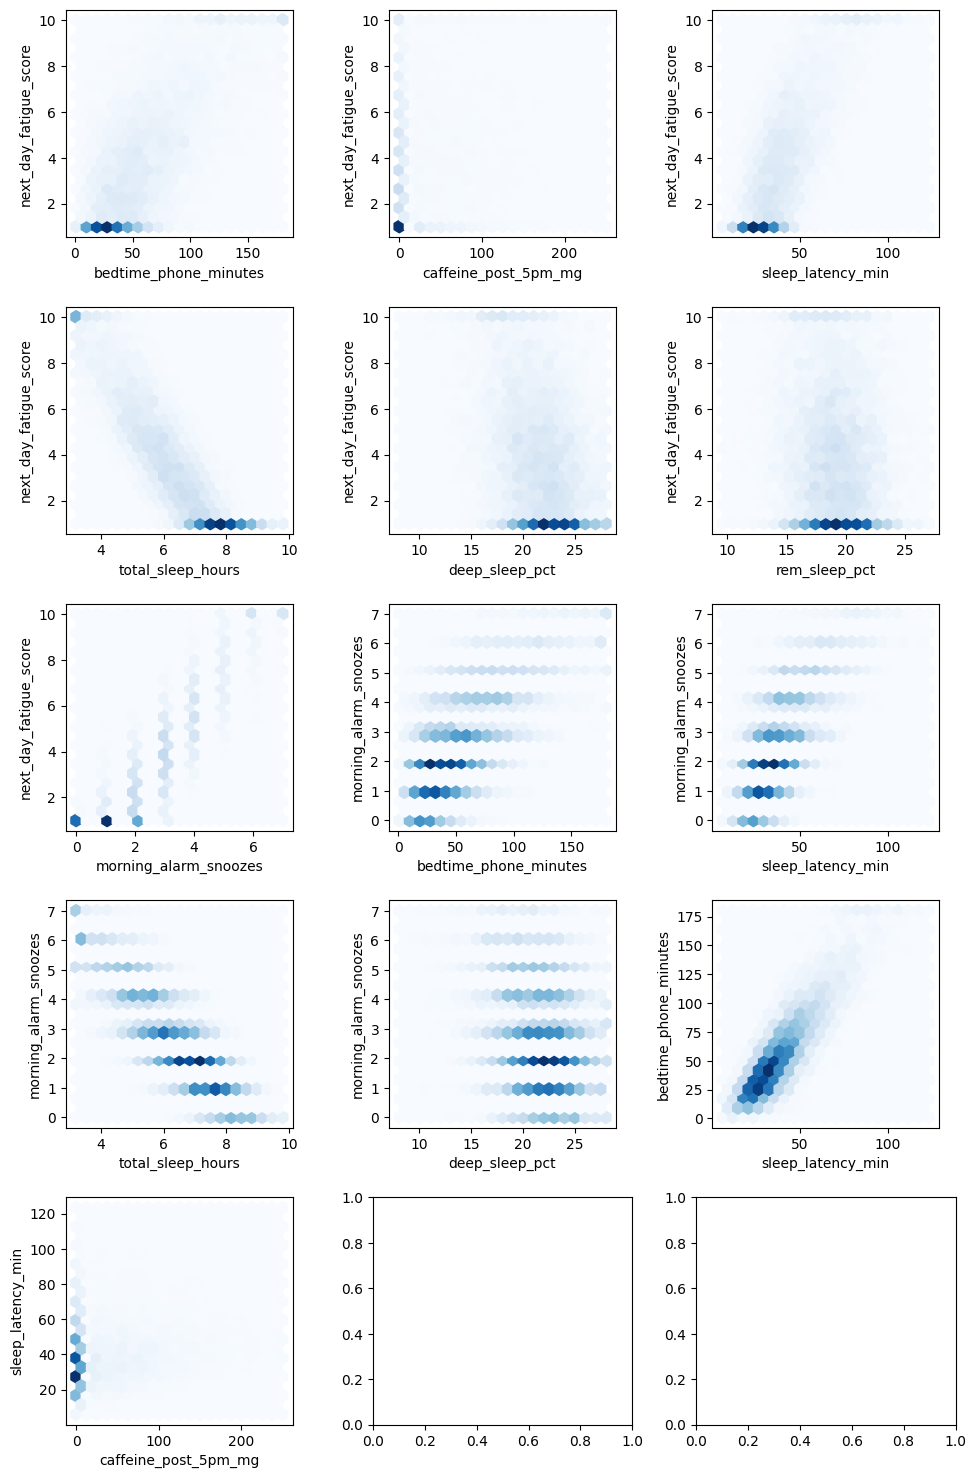

In [13]:
fig, axs = plt.subplots(5, 3, figsize = (10, 15))
axs = axs.flatten()

i = 0
for var_principal, variables in variables_lineal.items():
    for var in variables:
        axs[i].hexbin(df[var], df[var_principal], gridsize = 20, cmap = "Blues")
        axs[i].set_xlabel(var)
        axs[i].set_ylabel(var_principal)
        axs[i].set_box_aspect(1)
        i += 1
plt.tight_layout(pad=1.5)
plt.show()

Observaciones

1. Alta concentración de personas en:

        a. Uso del teléfono antes de dormir de 0 - 1 hora con un nivel fatiga en 0. En este mismo rango, nivel moderado bajo de personas con nivel de fatiga de 1 - 6

        b. Sin uso de cafeína y sin fatiga. Se detecta gente que sin consumo de cafeína, ya presenta fatiga [1 - 10], así como personas con cafeína sin fatiga (0)

        c. Sin fatiga, suele haber latencia de entre 0 - 1 hora.

        d. Sin fatiga, las personas suelen dormir entre 7 - 9 horas
        
        e. Sin fatiga, se ignora de 0 a 3 veces la alarma
        

In [20]:
df.columns.to_list()

['user_id',
 'age',
 'gender',
 'occupation_type',
 'chronotype',
 'bedtime_phone_minutes',
 'primary_bedtime_app',
 'screen_brightness_pct',
 'blue_light_filter_active',
 'caffeine_post_5pm_mg',
 'physical_activity_min',
 'sleep_latency_min',
 'total_sleep_hours',
 'deep_sleep_pct',
 'rem_sleep_pct',
 'morning_alarm_snoozes',
 'next_day_fatigue_score',
 'sleep_debt_category']

In [21]:
pd.crosstab(df["primary_bedtime_app"], df["sleep_debt_category"])

sleep_debt_category,Mild Deficit,Moderate Debt,Optimal Recovery,Severe Sleep Debt
primary_bedtime_app,,,,
Instagram / Reddit,383,867,255,125
Messaging / Chat,207,437,147,56
News / Reading,157,319,96,24
Streaming (Netflix/Hulu),312,687,229,73
TikTok / Reels,487,1141,332,238
YouTube,458,1011,328,131


In [22]:
pd.crosstab(df["blue_light_filter_active"], df["sleep_debt_category"])

sleep_debt_category,Mild Deficit,Moderate Debt,Optimal Recovery,Severe Sleep Debt
blue_light_filter_active,,,,
0,1016,2388,717,403
1,988,2074,670,244


# Análisis de datos de interés



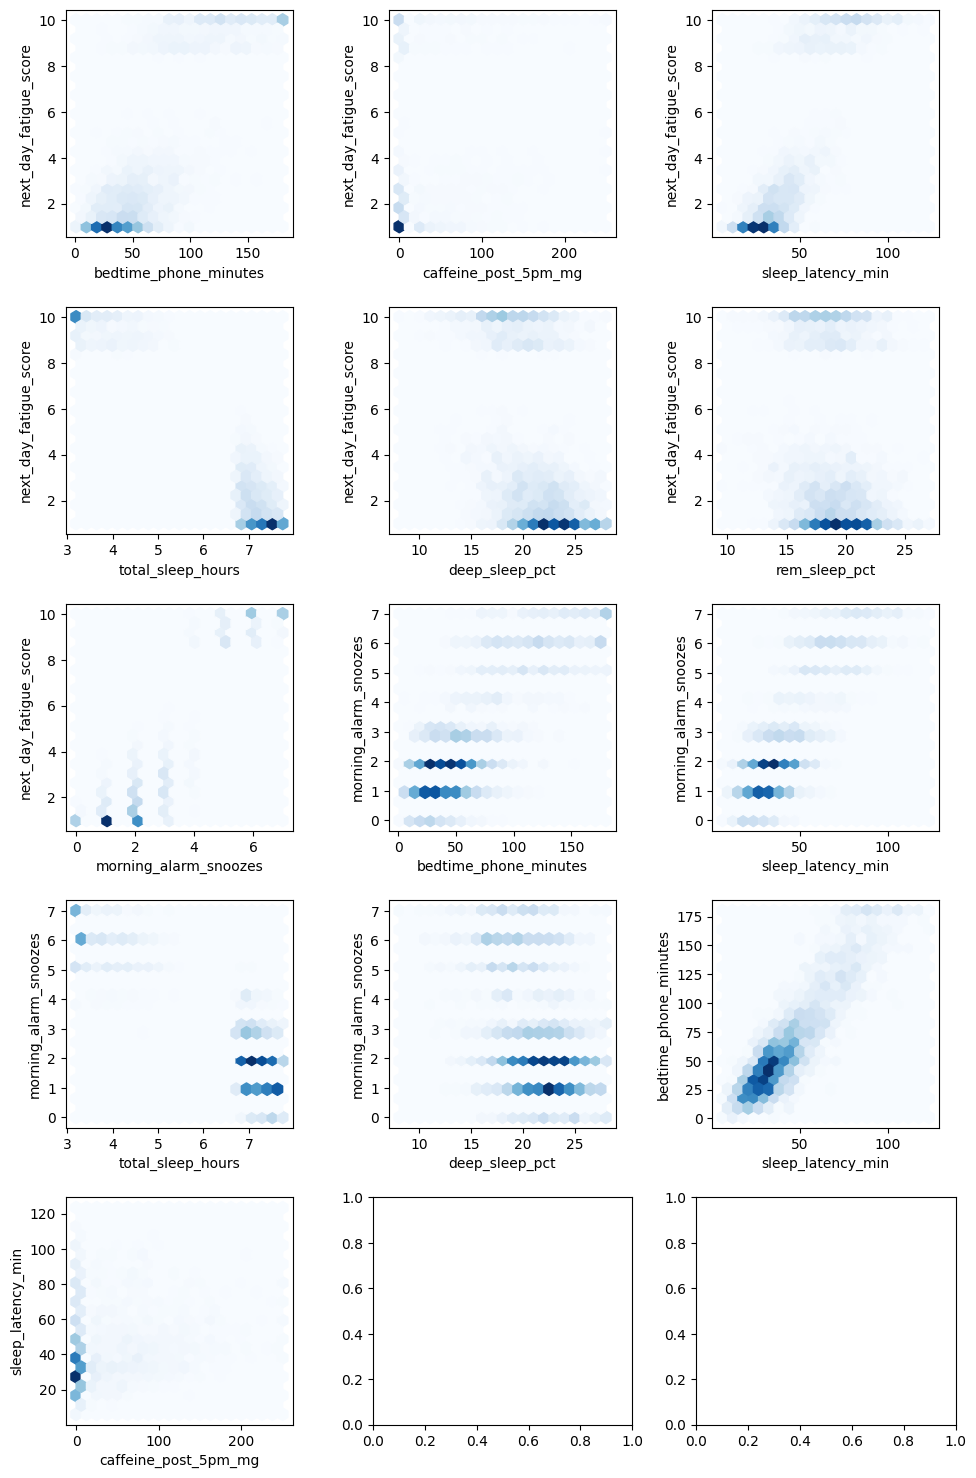

In [15]:
fig, axs = plt.subplots(5, 3, figsize = (10, 15))
axs = axs.flatten()

df_filtrado = df[(df["sleep_debt_category"] != "Moderate Debt")].copy()
df_filtrado = df_filtrado[df_filtrado["sleep_debt_category"] != "Optimal Recovery"].copy()

i = 0
for var_principal, variables in variables_lineal.items():
    for var in variables:
        axs[i].hexbin(df_filtrado[var], df_filtrado[var_principal], gridsize = 20, cmap = "Blues")
        axs[i].set_xlabel(var)
        axs[i].set_ylabel(var_principal)
        axs[i].set_box_aspect(1)
        i += 1
plt.tight_layout(pad=1.5)
plt.show()

Hipótesis inicial: Las personas pertenecientes a la categoría "Moderate Debt" y "Optimal Recovery" provocaban que el volumen de los datos tendieran a:
1. Hacer que la fatiga se concentre en un Score 0-1
2. La latencia de sueño se concentre en un rango de 0 - 50 min
3. El uso de cafeína después de las 5 esté en 0

Conclusión: 
Pertenecer a estas categorías no dispara indicadores de mala calidad de sueño de manera evidente

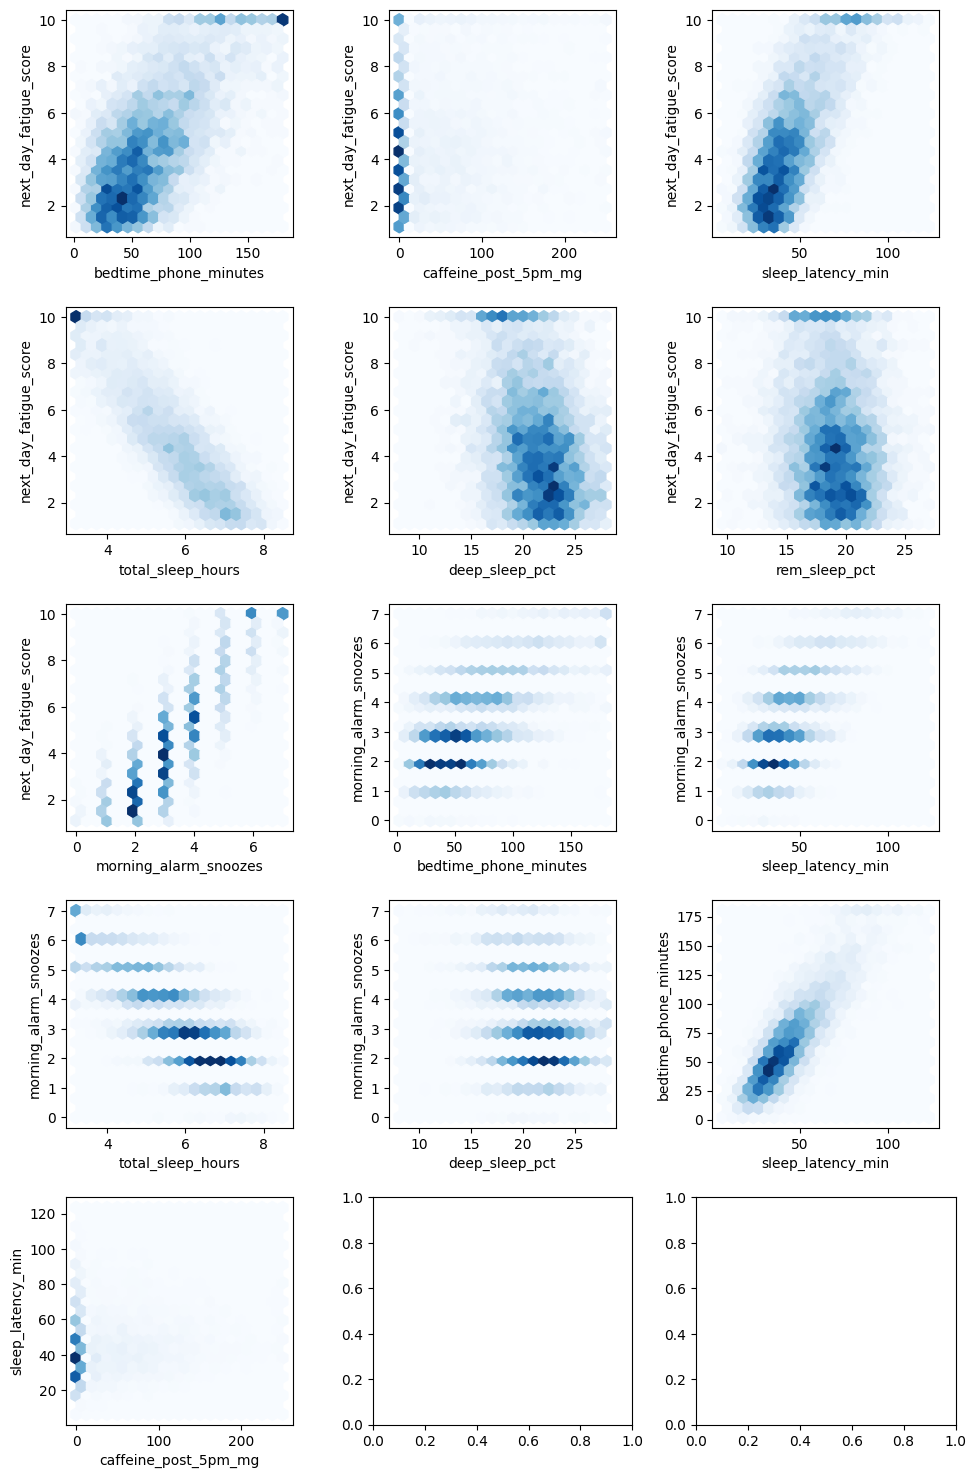

In [19]:
fig, axs = plt.subplots(5, 3, figsize = (10, 15))
axs = axs.flatten()

df_filtrado = df[df['next_day_fatigue_score'] > 1].copy()

i = 0
for var_principal, variables in variables_lineal.items():
    for var in variables:
        axs[i].hexbin(df_filtrado[var], df_filtrado[var_principal], gridsize = 20, cmap = "Blues")
        axs[i].set_xlabel(var)
        axs[i].set_ylabel(var_principal)
        axs[i].set_box_aspect(1)
        i += 1
plt.tight_layout(pad=1.5)
plt.show()

Observaciones: 

1. Eliminar a las personas con fatiga menor a 1 permite aislar a personas con algún tipo de problema de sueño

2. Luego de aproximadamente 10 minutos de uso continuo de teléfono el nivel de fatiga crece de forma recurrente.

3. Cafeína no es un factor COMÚN por el que la gente esté fatigada

4. El porcentaje de sueño REM y profundo no varía independientemente del nivel de fatiga, aunque las personas con una fatiga severa (10) tienen un sueño profundo inferior a la media, que es de 20 - 25%.



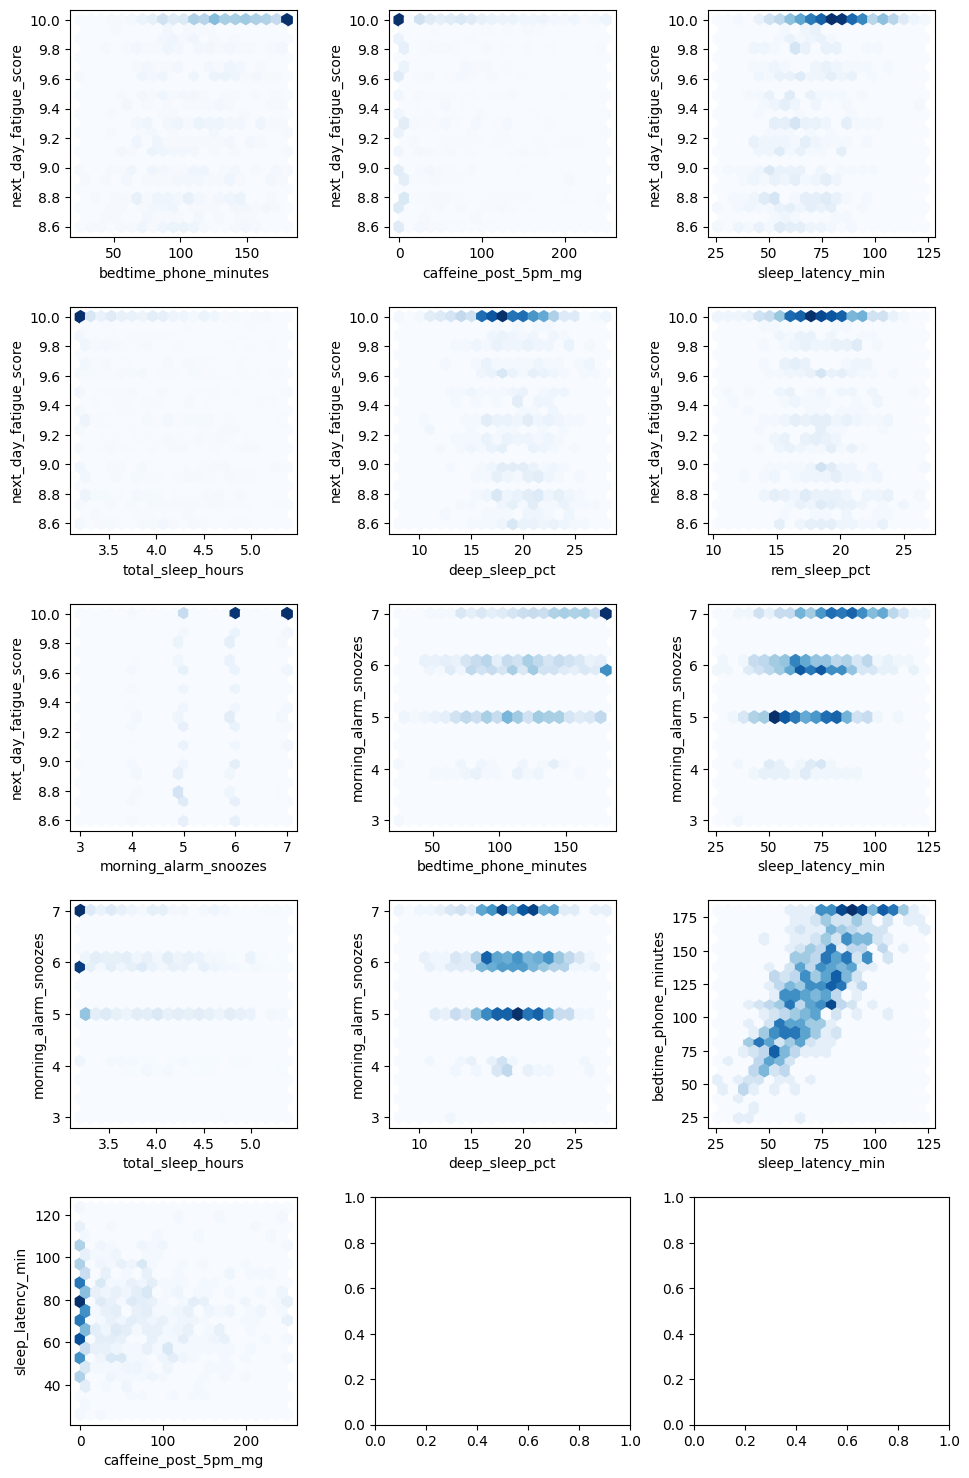

In [23]:
fig, axs = plt.subplots(5, 3, figsize = (10, 15))
axs = axs.flatten()

df_filtrado = df[(df["sleep_debt_category"] == "Severe Sleep Debt")].copy()

i = 0
for var_principal, variables in variables_lineal.items():
    for var in variables:
        axs[i].hexbin(df_filtrado[var], df_filtrado[var_principal], gridsize = 20, cmap = "Blues")
        axs[i].set_xlabel(var)
        axs[i].set_ylabel(var_principal)
        axs[i].set_box_aspect(1)
        i += 1
plt.tight_layout(pad=1.5)
plt.show()

Observaciones de quienes estan catalogados con una deuda de sueño severa

1. Usan el teléfono antes de dormir por más de 1 hora

2. La cafeína, si bien, a priori no afectó a la población de forma recurrente respeto al sueño, hay evidencia de que aquellas que consumían café después de las 5, solían tardar más de una hora para poder dormir.

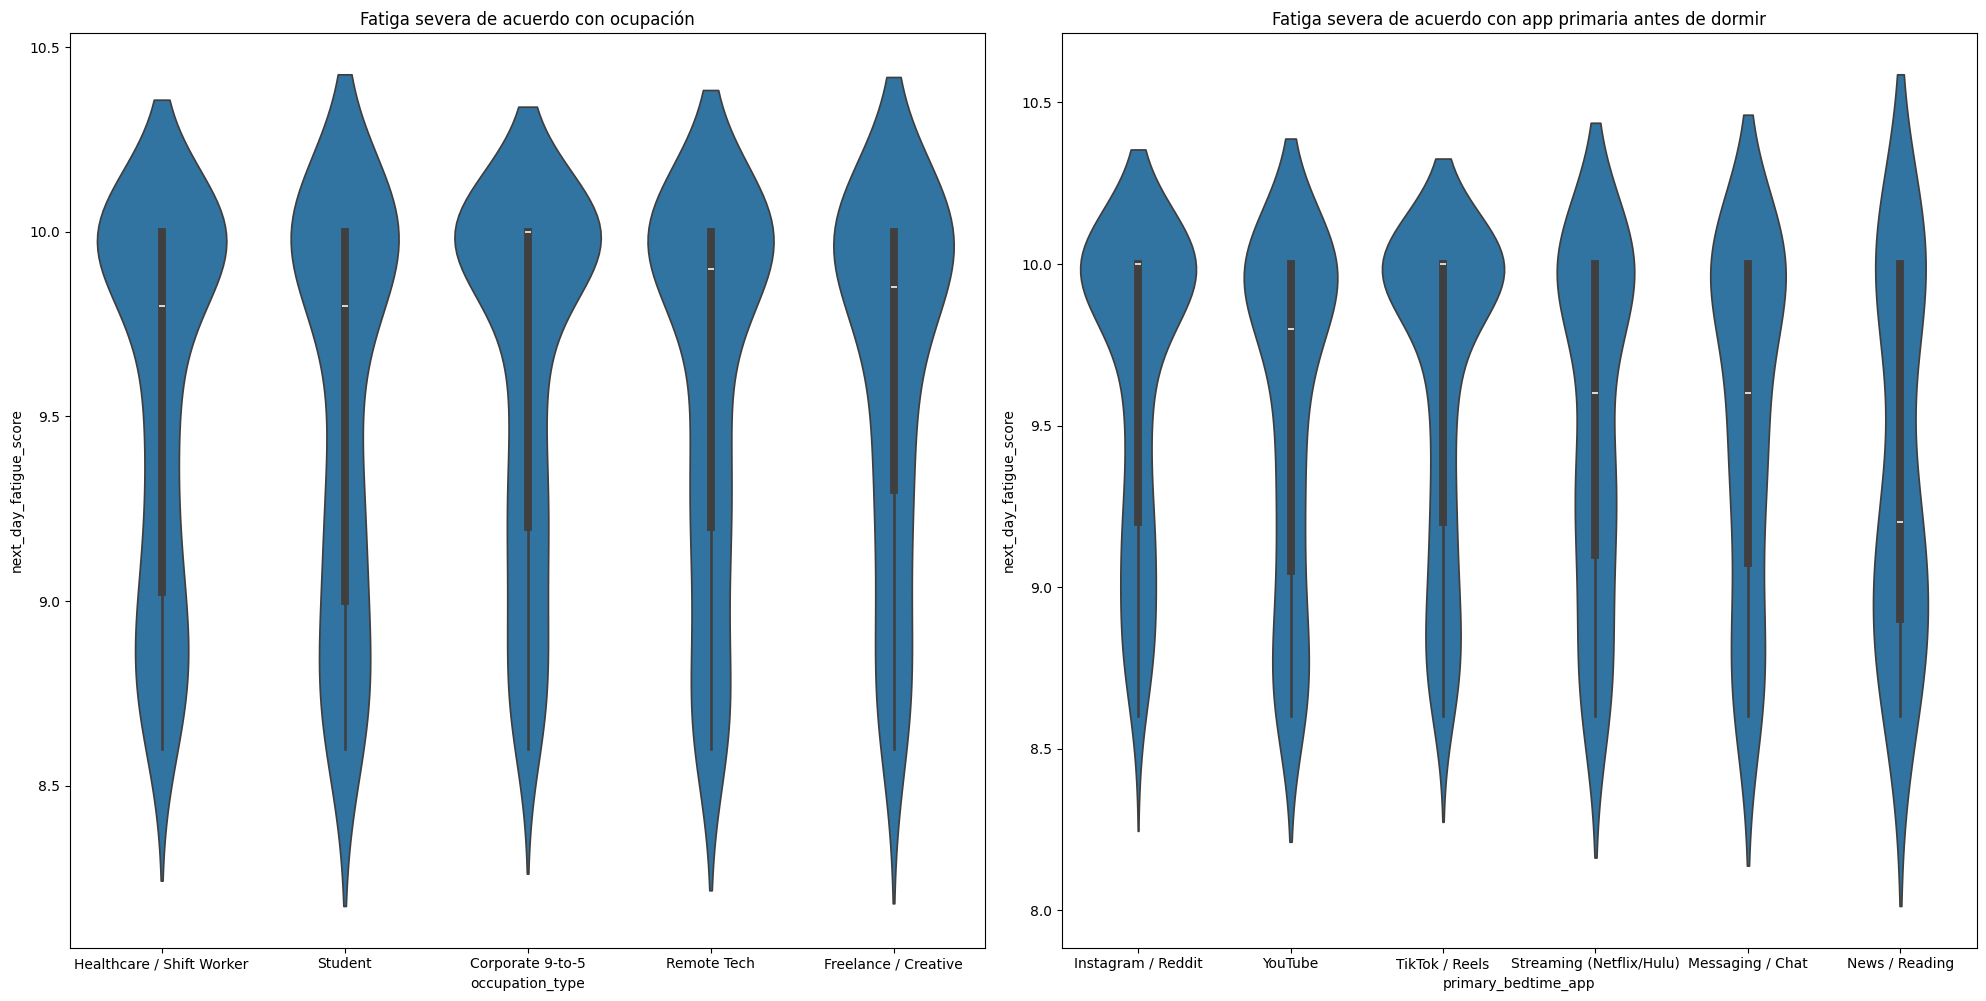

In [27]:
var_estudio = "next_day_fatigue_score"
variables = ["occupation_type", "primary_bedtime_app"]
titulos = ["Fatiga severa de acuerdo con ocupación", "Fatiga severa de acuerdo con app primaria antes de dormir"]

fig, axs = plt.subplots(1, 2, figsize = (20,30))
axs = axs.flatten()

df_filtrado = df[(df["sleep_debt_category"] == "Severe Sleep Debt")].copy()
for i, var in enumerate(variables):
    sns.violinplot(df_filtrado , x = var, y = var_estudio, ax = axs[i])
    axs[i].set_title(titulos[i])
    axs[i].set_box_aspect(1)


plt.tight_layout(pad= 1.2)
plt.show()

En niveles severos de fatiga, las personas más afectadas son las que se apegan a un horario fijo de 9 - 5 y que usan principalmente instagram/reddit y ven videos en formato corto.



**Conclusiones**

**Problema:** Una cantidad no despreciable de la población se siente cansada a lo largo del día.

**Recomendaciones**

1. Si se es persona que siente que es más productiva de noche, desistir.

2. No usar el teléfono antes de dormir. Pero si se usa, activar filtro de luz azul, usar el dispositivo menos de 10 minutos y de preferencia, no entrar a redes sociales tales como instagram o tiktok.

**Señales de advertencia**

Necesitar más de 3 alarmas para despertar

Necesitar más de una hora para poder dormir